## Lista de Exercícios da Disciplina Aprendizagem de Máquina

Professor: Dr. Leandro Carlos de Souza 

Alunos:
* Thiago Ney Evaristo Rodrigues
* Villeneve de Oliveira Soares

### Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score

random_state = 42

### Etapa 1 - Geração dos dados

Gere dois conjuntos de dados correspondentes a duas classes hipotéticas, seguindo distribuições normais bivariadas independentes:

* Classe 1:
$\mu _x = 25$, $\mu _y = 10$, $\sigma _x ^2 = 100$, $\sigma _y ^2 = 25$ e $N = 150 \ \text{Elementos}$.

* Classe 2:
$\mu _x = 60$, $\mu _y = 30$, $\sigma _x ^2 = 36$, $\sigma _y ^2 = 144$ e $N = 150 \ \text{Elementos}$.

Combine ambas as classes em um único conjunto de 300 pontos.

In [2]:
np.random.seed(random_state)

n_samples = 150

mu_zero = [25, 10]
cov_zero = [[100, 0], [0, 25]]

mu_one = [60, 30]
cov_one = [[36, 0], [0, 144]]

class_zero = np.random.multivariate_normal(mu_zero, cov_zero, n_samples)
df_zero = pd.DataFrame(class_zero, columns=["x", "y"])
df_zero["class"] = 0

class_one = np.random.multivariate_normal(mu_one, cov_one, n_samples)
df_one = pd.DataFrame(class_one, columns=["x", "y"])
df_one["class"] = 1

df = pd.concat((df_zero, df_one))
display(df)

data = df[["x", "y"]].values.T
class_true = df["class"].values

,x,y,class
0,29.967142,9.308678,0
1,31.476885,17.615149,0
2,22.658466,8.829315,0
3,40.792128,13.837174,0
4,20.305256,12.712800,0
...,...,...,...
145,57.134055,30.858795,1
146,62.001973,35.747758,1
147,56.939902,42.450479,1
148,54.127418,26.761501,1


### Etapa 2 - Aplicação do K-means

1. Aplique o algoritmo K-means com $k=2$.
2. Visualize os clusters resultantes, plotando o agrupamento em cores diferentes.
3. Calcule a matriz de confusão.
4. Calcule o índice de Rand ajustado para esse agrupamento.

In [3]:
kmeans = KMeans(n_clusters=2, random_state=random_state, n_init="auto")
class_pred = kmeans.fit_predict(df.iloc[:, 0:2])

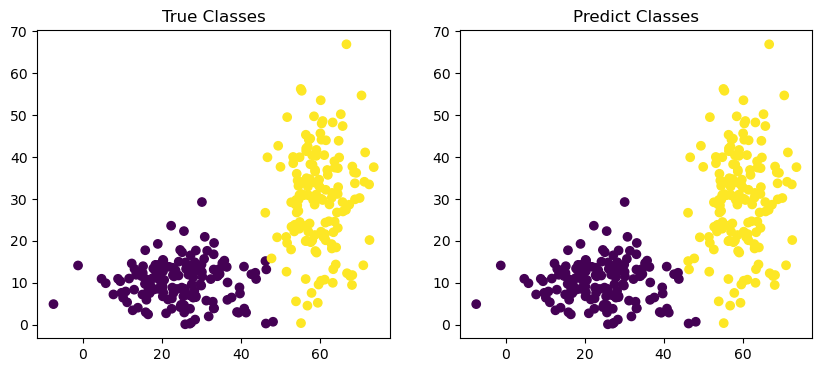

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].scatter(df.loc[:, "x"], df.loc[:, "y"], c=df.loc[:, "class"])
axs[0].set_title("True Classes")
axs[1].scatter(df.loc[:, "x"], df.loc[:, "y"], c=class_pred)
axs[1].set_title("Predict Classes");

Text(0.5, 1.0, 'Confusion Matrix')

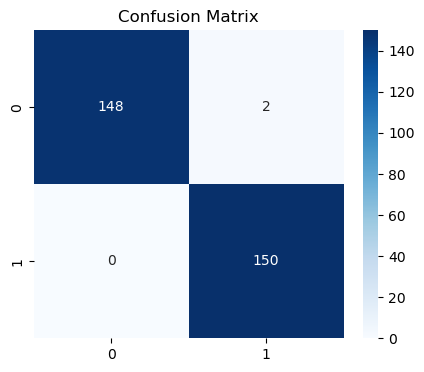

In [5]:
cm = confusion_matrix(class_true, class_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, fmt="d", annot=True, cmap="Blues")
plt.title("Confusion Matrix")

In [6]:
ari = adjusted_rand_score(class_true, class_pred)
print(f"O Índice de Rand Ajustado (ARI) é: {ari:.4f}")

O Índice de Rand Ajustado (ARI) é: 0.9734


### Etapa 3 - Aplicação do Fuzzy C-means

1. Aplique o algoritmo Fuzzy C-means (use $c=2$).
2. Analise os graus de pertinência (membership) de cada ponto a cada cluster.
3. Plote os pontos colorindo-os de acordo com o grau de pertinência à Classe 1 (por exemplo, intensidade da cor → grau de pertencimento).

In [7]:
c = 2
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data, c, m=2.0, error=0.005, maxiter=1000, seed=random_state
)

print(f"Centros dos clusters:\n{cntr}\n")
print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")

Centros dos clusters:
[[59.47418797 30.76989607]
 [24.27498701 10.16440833]]

Fuzzy Partition Coefficient (FPC): 0.8738


In [8]:
u_df = pd.DataFrame(u.T, columns=[f"Cluster_{i}" for i in range(c)])
df = df.reset_index(drop=True)
u_df = u_df.reset_index(drop=True)
df = pd.concat([df, u_df], axis=1)

display(df)

,x,y,class,Cluster_0,Cluster_1
0,29.967142,9.308678,0,0.024284,0.975716
1,31.476885,17.615149,0,0.100896,0.899104
2,22.658466,8.829315,0,0.002387,0.997613
3,40.792128,13.837174,0,0.310512,0.689488
4,20.305256,12.712800,0,0.011821,0.988179
...,...,...,...,...,...
295,57.134055,30.858795,1,0.996376,0.003624
296,62.001973,35.747758,1,0.985221,0.014779
297,56.939902,42.450479,1,0.936571,0.063429
298,54.127418,26.761501,1,0.963134,0.036866


In [10]:
cntr

array([[59.47418797, 30.76989607],
       [24.27498701, 10.16440833]])

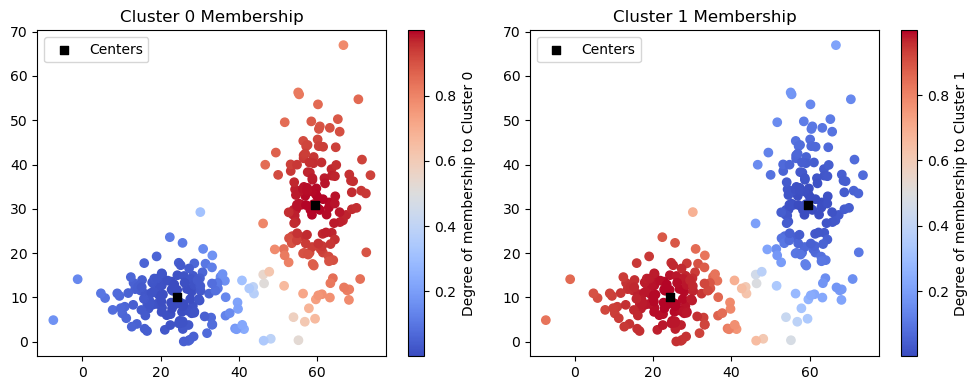

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

scatter0 = axs[0].scatter(df["x"], df["y"], c=df["Cluster_0"], cmap="coolwarm")
fig.colorbar(scatter0, ax=axs[0], label="Degree of membership to Cluster 0")
axs[0].scatter(cntr[:, 0], cntr[:, 1], marker="s", c="black", label="Centers")
axs[0].set_title("Cluster 0 Membership")
axs[0].legend()

scatter1 = axs[1].scatter(df["x"], df["y"], c=df["Cluster_1"], cmap="coolwarm")
fig.colorbar(scatter1, ax=axs[1], label="Degree of membership to Cluster 1")
axs[1].scatter(cntr[:, 0], cntr[:, 1], marker="s", c="black", label="Centers")
axs[1].set_title("Cluster 1 Membership")
axs[1].legend()

plt.tight_layout()

### Etapa 4 - Aplicação da Regressão Logística

1. Treine um modelo de Regressão Logística para classificar as duas classes verdadeiras.
2. Plote a fronteira de decisão obtida pelo modelo.
3. Calcule as métricas de desempenho (acurácia, precisão, recall, F1-score).

### Etapa 5 - Rede Neural Artificial

1. Crie e treine uma rede neural totalmente conectada (feedforward)
2. Plote a fronteira de decisão da RNA e compare com a da Regressão Logística.
3. Calcule as métricas de desempenho (acurácia, precisão, recall, F1-score).

### Etapa 6 - Máquina de Vetores de Suporte (SVM)

1. Treine um modelo de SVM.
2. Plote a fronteira de decisão obtida pelo SVM.
3. Calcule as métricas de desempenho (acurácia, precisão, recall, F1-score).

### Etapa 7 - Árvore de Decisão

1. Treine uma Árvore de Decisão para classificar as duas classes.
2. Visualize a árvore e a fronteira de decisão no espaço.
3. Avalie métricas de desempenho: acurácia, precisão, recall, F1-score.

### Etapa 8 - K-Vizinhos Mais Próximos (KNN)

1. Treine um modelo KNN usando os dados de treino.
2. Plote a fronteira de decisão para cada $k$.
3. Compare métricas de desempenho (acurácia, precisão, recall, F1-score) com os outros
modelos.
